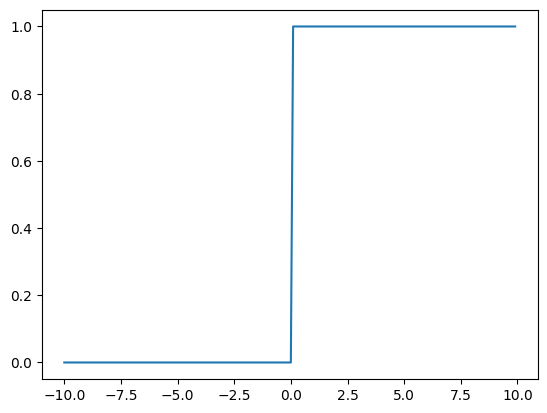

In [259]:
import matplotlib.pyplot as plt
import numpy as np

wx = np.arange(-10,10,0.1)
plt.plot(wx,wx > 0)

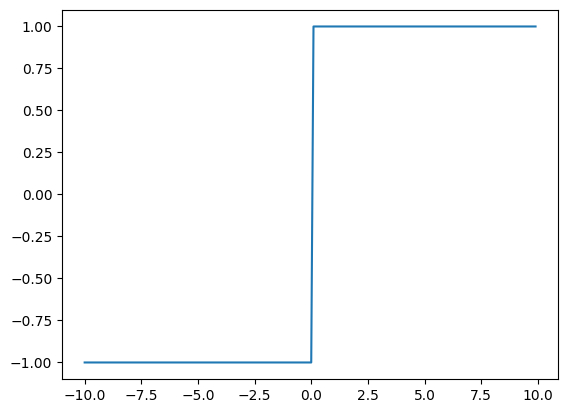

In [260]:
wx = np.arange(-10,10,0.1)
plt.plot(wx,(wx > 0)*2-1)

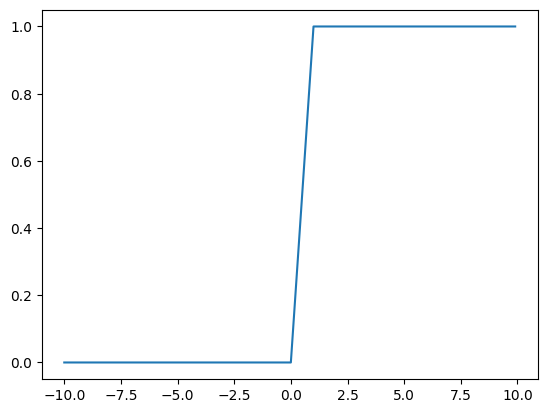

In [261]:
wx = np.arange(-10,10,0.1)
plt.plot(wx,np.array([min(max(e,0),1) for e in list(wx)]))

In [262]:
np.max(wx)

np.float64(9.899999999999928)

## Sigmoid Unit

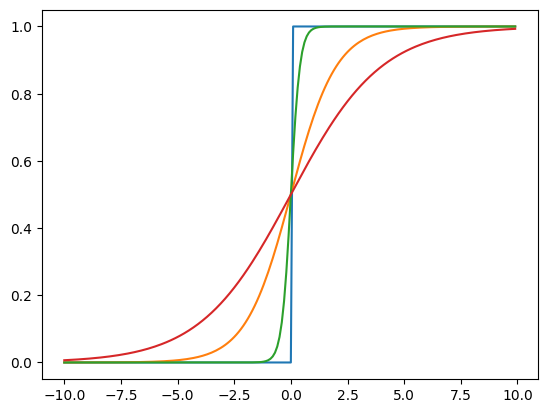

In [263]:
wx = np.arange(-10,10,0.1)
plt.plot(wx,wx>0)
plt.plot(wx,1/(1+np.exp(-wx)))
plt.plot(wx,1/(1+np.exp(-5*wx)))
plt.plot(wx,1/(1+np.exp(-0.5*wx)))

## ReLU

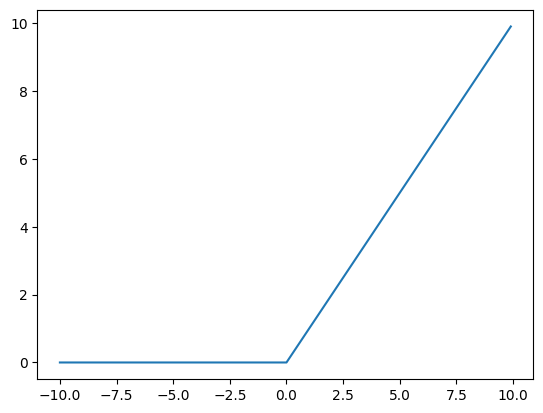

In [264]:
wx = np.arange(-10,10,0.1)
plt.plot(wx,np.array([max(e,0) for e in list(wx)]))

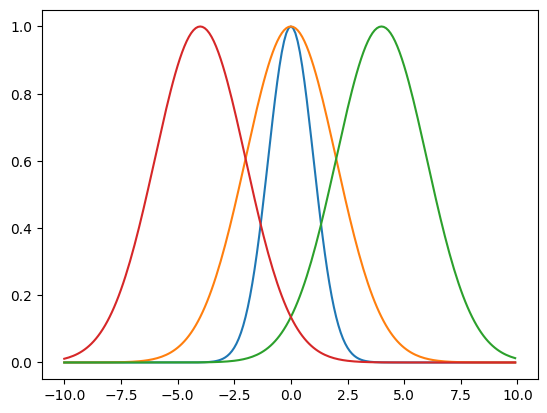

In [265]:
plt.plot(wx,np.exp(-(wx-0)**2/(2*1**2)))
plt.plot(wx,np.exp(-(wx-0)**2/(2*2**2)))
plt.plot(wx,np.exp(-(wx-4)**2/(2*2**2)))
plt.plot(wx,np.exp(-(wx-(-4))**2/(2*2**2)))




### Comparing for each Activation function
1. Relu
2. Sigmoid
3. Tanh
4. linear
5. clipper-linear

#### Preparing data

In [266]:
n_data = 300
epoch = 1000
threshold = 0.5
learning_rate = 0.00001
x = np.linspace(-5, 5, n_data).reshape(-1, 1)
y = 5*np.cos(x)

In [267]:
act_func = [
    lambda x: np.maximum(0, x), 
    lambda x: 1 / (1 + np.exp(-x)), 
    lambda x: np.tanh(x), 
    lambda x: x, 
    lambda x: np.clip(x, -1, 1)
]

In [268]:
fname = {
    0: "Relu",
    1: "Sigmoid",
    2: "Tanh",
    3: "Linear",
    4: "Clipper-linear"
}

In [269]:
diff = {
    0: lambda x: (x > 0).astype(float),
    1: lambda x: x*(1-x),
    2: lambda x: 1-x**2,
    3: lambda x: np.ones_like(x),
    4: lambda x: ((x > -1) & (x < 1)).astype(float)
}

In [270]:
n_hidden = 200
master_wi1 = np.random.uniform(-0.5, 0.5, (1, n_hidden))
master_bi1 = np.random.uniform(-0.5, 0.5, (1, n_hidden))
master_wi2 = np.random.uniform(-0.5, 0.5, (n_hidden, 1))
master_bi2 = np.random.uniform(-0.5, 0.5, (1, 1))

In [271]:
results = []
for i in range(5):
    results.append([])
    r = act_func[i](x @ master_wi1 + master_bi1)@master_wi2 + master_bi2
    results[i].append(r)

In [272]:
len(results[0])

1

In [273]:
for i, fn in enumerate(act_func):
    wi1 = master_wi1.copy()
    wi2 = master_wi2.copy()
    bi1 = master_bi1.copy()
    bi2 = master_bi2.copy()

    for e in range(epoch):
        ri1 = x @ wi1 + bi1 
        fi1 = fn(ri1)            
        ri2 = fi1 @ wi2 + bi2 

        deltak = ri2 - y  
        deltah = (deltak @ wi2.T) * diff[i](fi1)

        wi2 -= learning_rate * (fi1.T @ deltak)
        bi2 -= learning_rate * np.sum(deltak, axis=0, keepdims=True)
        
        wi1 -= learning_rate * (x.T @ deltah)
        bi1 -= learning_rate * np.sum(deltah, axis=0, keepdims=True)

        r = fn(x @ wi1 + bi1)@wi2 + bi2
        results[i].append(r)

In [274]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.pyplot as plt

In [275]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(-5, 5) # หรือตามช่วง x ที่คุณพาวใช้
ax.set_ylim(-10, 10)

ax.plot(x, y, 'r--', label='Target (Cos)', alpha=0.5)

line, = ax.plot([], [], 'b-', lw=2, label='Neural Network')
title = ax.set_title('')

def update(epoch):
    y_pred = results[0][epoch] 
    
    line.set_data(x, y_pred)
    title.set_text(f'Epoch: {epoch} (Activation: ReLU)')
    return line, title

frames = range(0, len(results[0]), 5) 
anim = FuncAnimation(fig, update, frames=frames, interval=50, blit=True)

plt.close()

HTML(anim.to_html5_video())

In [276]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(-5, 5) 
ax.set_ylim(-10, 10)

ax.plot(x, y, 'r--', label='Target (Cos)', alpha=0.5)

line, = ax.plot([], [], 'b-', lw=2, label='Neural Network')
title = ax.set_title('')

def update(epoch):
    y_pred = results[1][epoch] 
    
    line.set_data(x, y_pred)
    title.set_text(f'Epoch: {epoch} (Activation: {fname[1]})')
    return line, title

frames = range(0, len(results[0]), 5) 
anim = FuncAnimation(fig, update, frames=frames, interval=50, blit=True)

plt.close()

HTML(anim.to_html5_video())

In [277]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(-5, 5) 
ax.set_ylim(-10, 10)

ax.plot(x, y, 'r--', label='Target (Cos)', alpha=0.5)

line, = ax.plot([], [], 'b-', lw=2, label='Neural Network')
title = ax.set_title('')

def update(epoch):
    y_pred = results[2][epoch] 
    
    line.set_data(x, y_pred)
    title.set_text(f'Epoch: {epoch} (Activation: {fname[2]})')
    return line, title

frames = range(0, len(results[0]), 5) 
anim = FuncAnimation(fig, update, frames=frames, interval=50, blit=True)

plt.close()

HTML(anim.to_html5_video())

In [278]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(-5, 5) 
ax.set_ylim(-10, 10)

ax.plot(x, y, 'r--', label='Target (Cos)', alpha=0.5)

line, = ax.plot([], [], 'b-', lw=2, label='Neural Network')
title = ax.set_title('')

def update(epoch):
    y_pred = results[3][epoch] 
    
    line.set_data(x, y_pred)
    title.set_text(f'Epoch: {epoch} (Activation: {fname[3]})')
    return line, title

frames = range(0, len(results[0]), 5) 
anim = FuncAnimation(fig, update, frames=frames, interval=50, blit=True)

plt.close()

HTML(anim.to_html5_video())

In [279]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(-5, 5) 
ax.set_ylim(-10, 10)

ax.plot(x, y, 'r--', label='Target (Cos)', alpha=0.5)

line, = ax.plot([], [], 'b-', lw=2, label='Neural Network')
title = ax.set_title('')

def update(epoch):
    y_pred = results[4][epoch] 
    
    line.set_data(x, y_pred)
    title.set_text(f'Epoch: {epoch} (Activation: {fname[4]})')
    return line, title

frames = range(0, len(results[0]), 5) 
anim = FuncAnimation(fig, update, frames=frames, interval=50, blit=True)

plt.close()

HTML(anim.to_html5_video())